# AirBnB
https://insideairbnb.com/get-the-data/

https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2025-12-28/data/listings.csv.gz

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../listings.csv')

In [3]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN


In [4]:
df.room_type

0        Entire home/apt
1        Entire home/apt
2        Entire home/apt
3           Private room
4        Entire home/apt
              ...       
43063    Entire home/apt
43064       Private room
43065    Entire home/apt
43066       Private room
43067       Private room
Name: room_type, Length: 43068, dtype: str

In [5]:
col_interes = ['id', 'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [6]:
df_treatment = df[col_interes].copy()

In [7]:
df_treatment.head(3)

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,821198084644106078,Bright and Peaceful Leblon Loft,Katrina,"Minnesota, United States",within an hour,f,"Rio de Janeiro, Brazil",Leblon,-22.982818,-43.222457,...,4,1.5,2.0,3.0,$580.00,2,86,2,4.93,f
1,821198370698658112,Copacabana 100% reformado.,Patrick,"Rio de Janeiro, Brazil",within an hour,f,"Rio de Janeiro, Brazil",Copacabana,-22.984090,-43.191770,...,2,2.0,1.0,1.0,"$1,900.00",5,0,0,NaN,f
2,821200521820144734,hambiente familia,Vanessa,NaN,NaN,f,NaN,Pavuna,-22.814911,-43.379011,...,4,1.0,1.0,1.0,$700.00,1,0,0,NaN,t


In [8]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [9]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      35890 non-null  str    
 5   host_is_superhost       41613 non-null  str    
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [10]:
df.host_response_time.value_counts()

host_response_time
within an hour        22227
within a few hours     6131
within a day           4258
a few days or more     3274
Name: count, dtype: int64

In [11]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [12]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [13]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [14]:
pd.set_option('display.max_rows', 10)

In [15]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [16]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

# 3. Verifique o resultado
print(df_treatment[['neighbourhood_cleansed', 'bairro_perigoso']].head(100))

      neighbourhood_cleansed  bairro_perigoso
0                     Leblon                0
1                 Copacabana                0
2                     Pavuna                1
3                     Leblon                0
4            Barra da Tijuca                0
..                       ...              ...
95               Jacarepaguá                0
96           Jardim Botânico                0
97  Recreio dos Bandeirantes                0
98                  Flamengo                0
99                  Botafogo                0

[100 rows x 2 columns]


In [17]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns 

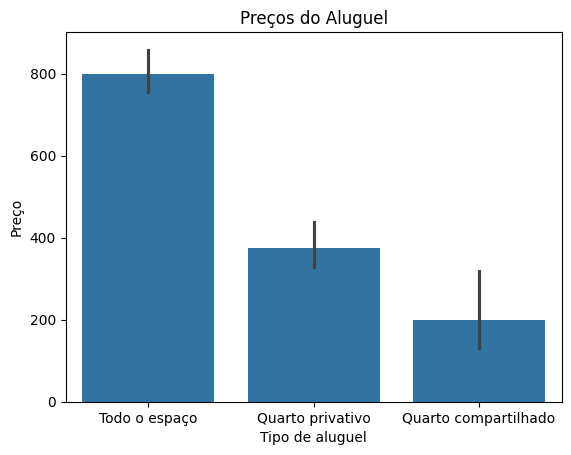

In [19]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

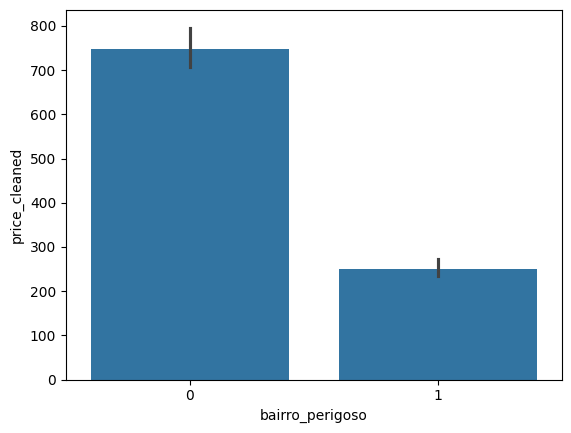

In [20]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [21]:
df_treatment.minimum_nights.describe()

count    43068.000000
mean         3.652155
std         15.394401
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: minimum_nights, dtype: float64

In [22]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [23]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      43068 non-null  str    
 5   host_is_superhost       43068 non-null  bool   
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [24]:
df_treatment.price_cleaned.describe()

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: price_cleaned, dtype: float64

**💡 Evidência de Outliers nos Preços**

A distribuição dos preços apresenta fortes indícios de valores discrepantes (outliers):

- Média inflacionada: A média está em 4.388, enquanto o terceiro quartil (75%) é de apenas 565 (ou seja, 75% dos anúncios custam até 565).
- Alta dispersão: O desvio padrão supera o valor do próprio percentil de 75%, mostrando uma variação extrema.
- Máximo discrepante: O valor máximo está excessivamente alto em comparação com o restante dos dados.

Ação: Vamos realizar o corte (trimming) desses outliers acima de 565 para normalizar a análise.

In [25]:
df_treatment = df_treatment[df_treatment["price_cleaned"] <=1000] 
df_treatment.price_cleaned.describe()

count    34359.000000
mean       348.797899
std        211.677365
min         30.000000
25%        193.000000
50%        286.000000
75%        452.000000
max       1000.000000
Name: price_cleaned, dtype: float64

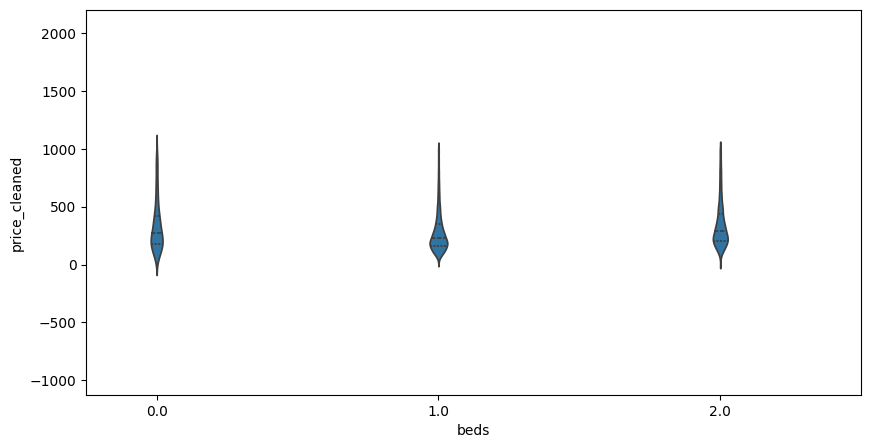

In [26]:
import seaborn as sns

plt.figure(figsize=[10,5])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()


0 camas nos anuncios? Provavlemente algum erro dos anuncios, portanto vamos verificar a quantidade que isso ocorre, se o melhor a se fazer é limpar, ou arrumar automaticamente

In [27]:
print("A quantidade de quartos com 0 camas é:", len(df_treatment[df_treatment["beds"] == 0]))

print("A quantidade total de anuncios é:", len(df_treatment))

A quantidade de quartos com 0 camas é: 389
A quantidade total de anuncios é: 34359


Pode ser limpo esses dados sem problemas na análise

In [28]:
df_treatment = df_treatment[df_treatment["beds"]>0]

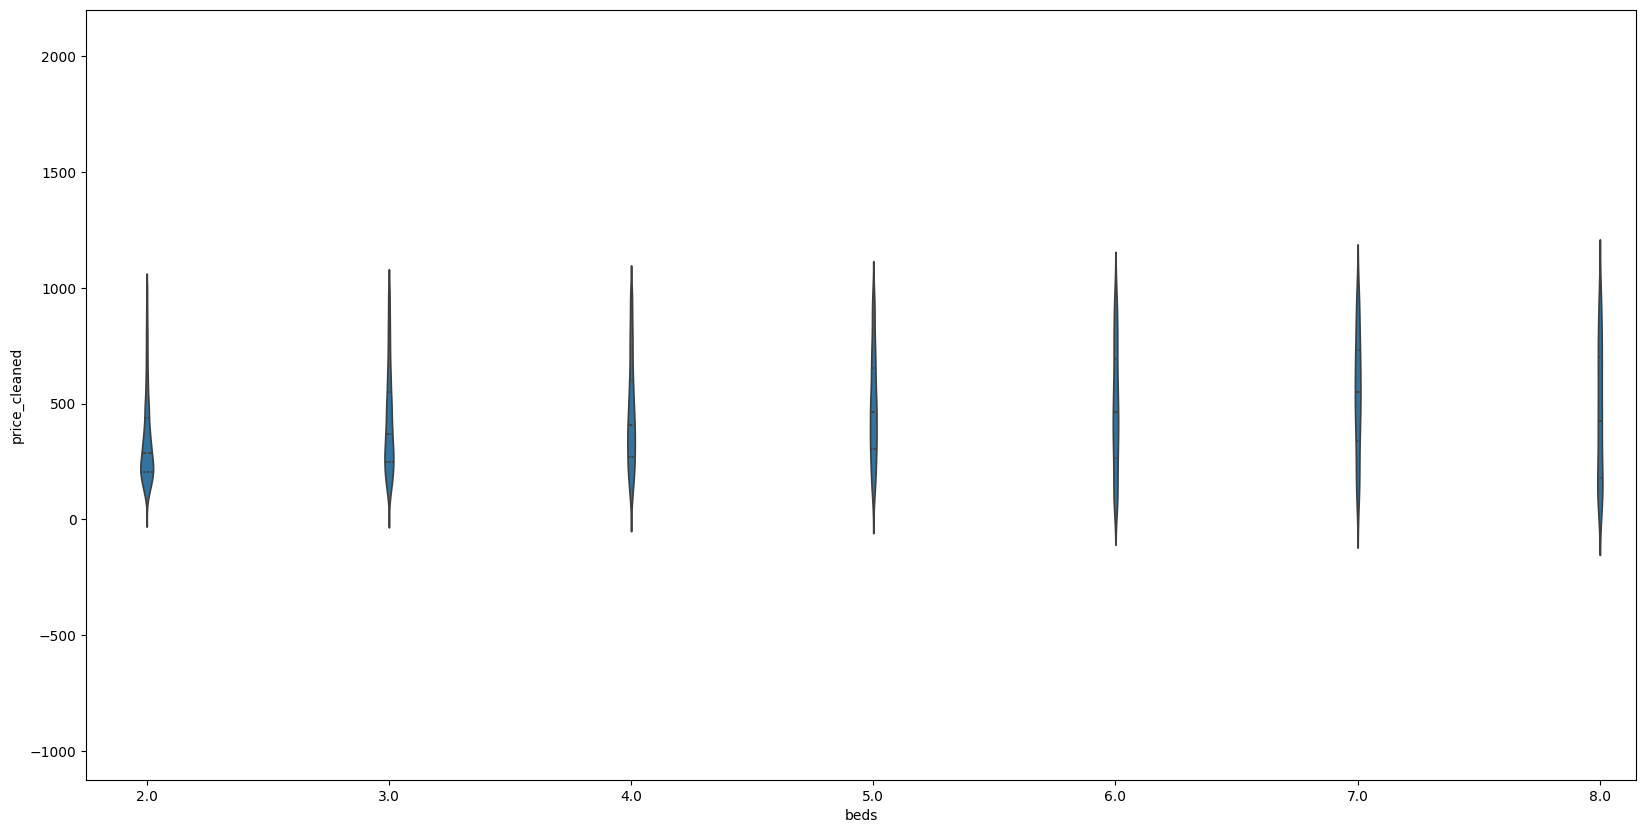

In [29]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(.75,7.15)

plt.show()


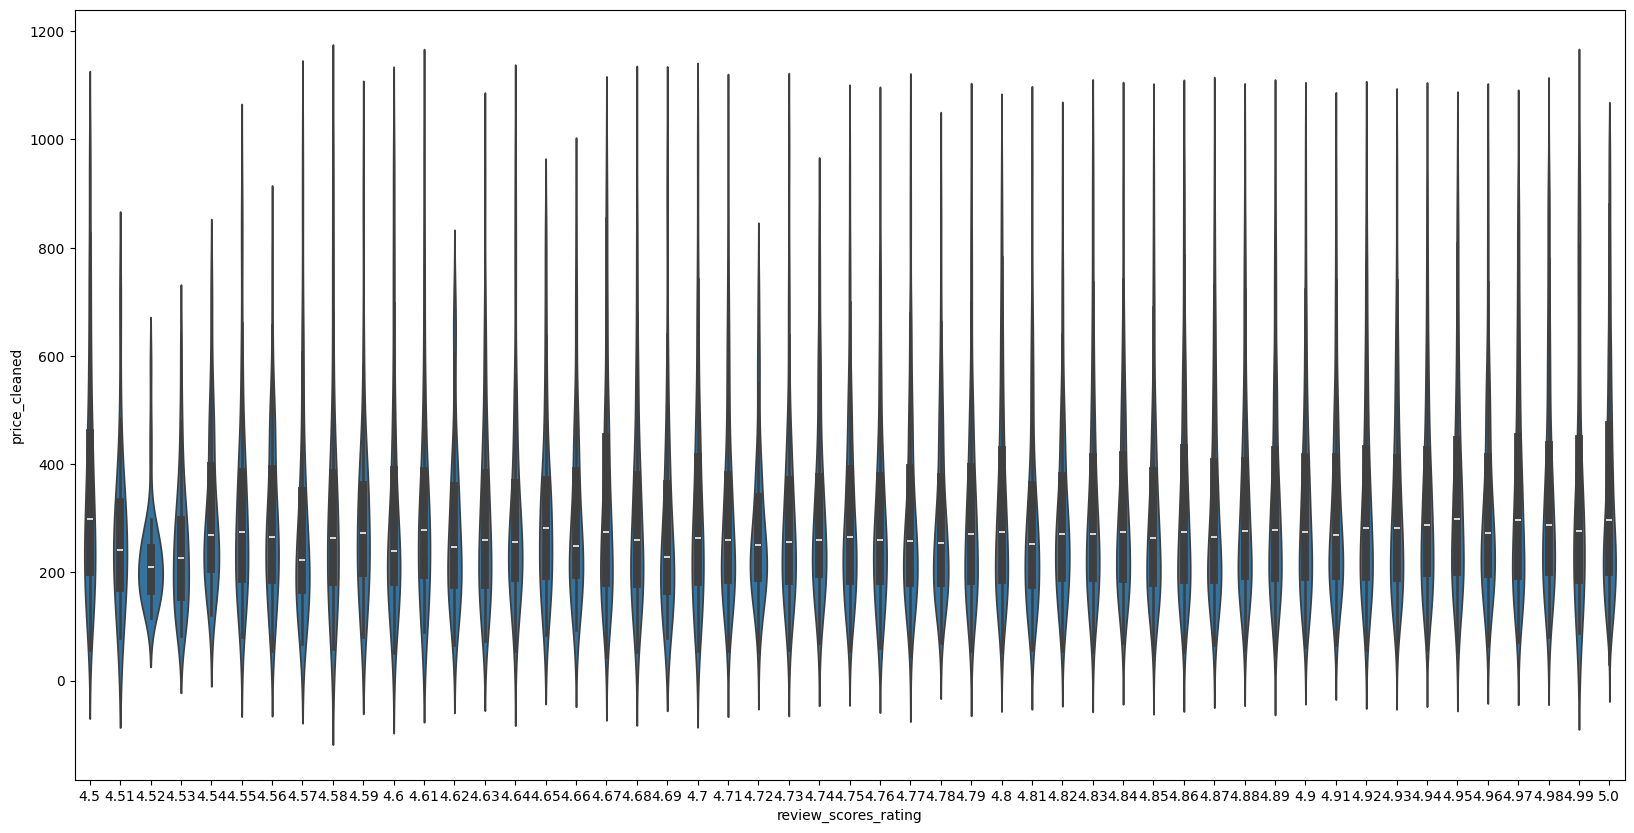

In [30]:
import seaborn as sns

plt.figure(figsize=[20,10])

df_plot_filtrado = df_treatment[
    df_treatment["review_scores_rating"].between(4.5, 5)
]

ax = sns.violinplot(x="review_scores_rating", y="price_cleaned", data=df_plot_filtrado)

# plt.xlim(4,5.1)

plt.show()


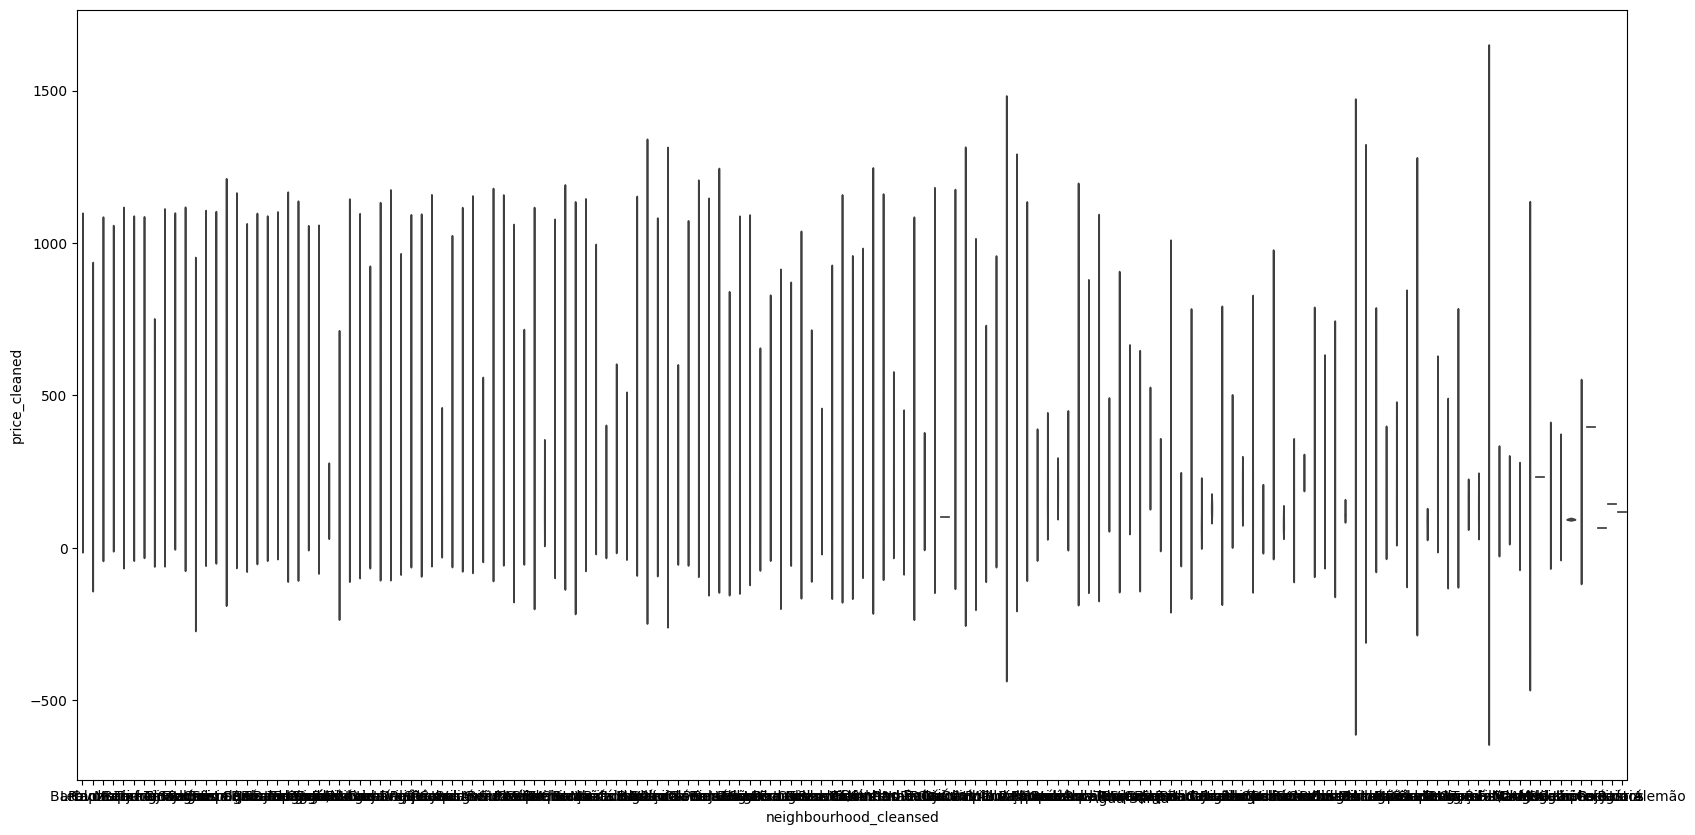

In [31]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="neighbourhood_cleansed", y="price_cleaned", data=df_treatment, inner=None)

# ax.set_yscale("log")

plt.show()


In [32]:
df_treatment['bairro_perigoso'].value_counts()

bairro_perigoso
0    31736
1     2223
Name: count, dtype: int64

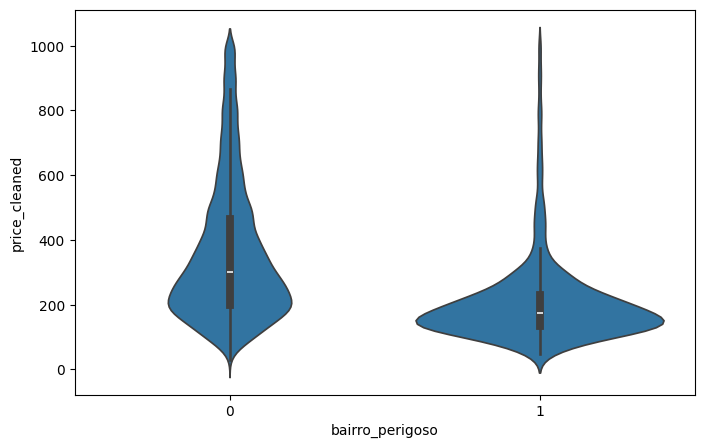

In [33]:
import seaborn as sns

plt.figure(figsize=[8,5])

ax = sns.violinplot(x="bairro_perigoso", y="price_cleaned", data=df_treatment)

# plt.xlim(4,5.1)

plt.show()


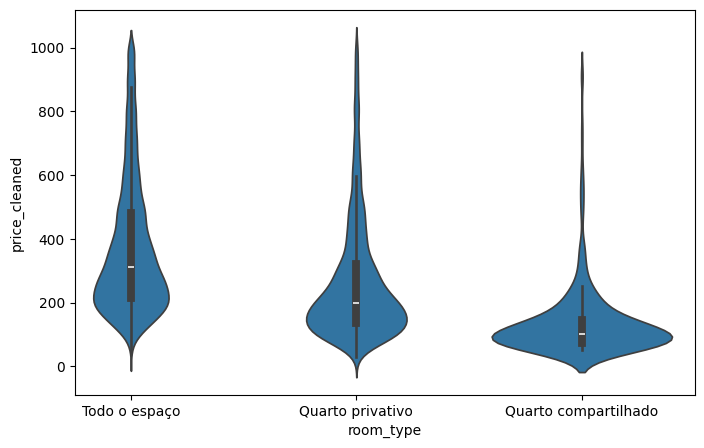

In [34]:
plt.figure(figsize=[8,5])

ax = sns.violinplot(df_treatment, x='room_type', y='price_cleaned')

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()

## Regressão sem Cuidado de Bairros ou Tipo de Quartos


### DecisionTree

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'room_type', 'review_scores_rating'
    ]].copy()

df_arvore_regressora.dropna(inplace=True)

Primeiro vamos tratar separando os room types

In [36]:
df_arvore_regressora.room_type.value_counts()

room_type
Todo o espaço           22930
Quarto privativo         4738
Quarto compartilhado      264
Name: count, dtype: int64

In [37]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

Text(0.5, 1.0, 'Correlation Heatmap')

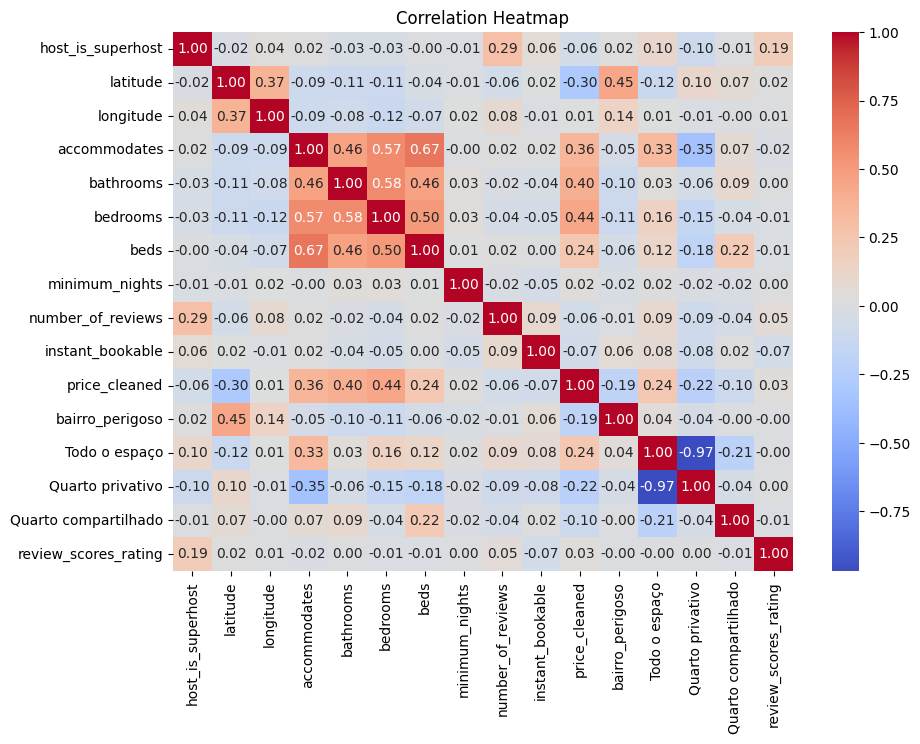

In [38]:
corr = df_arvore_regressora[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado', 'review_scores_rating'
]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [39]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [40]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [41]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=6, 
    min_samples_leaf=100,
    random_state=RANDOM_SEED
    )

In [42]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [43]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [44]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [45]:
y_pred_arvore = pipeline_arvore.predict(X_test)

In [46]:
print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.33502194484552517
Root mean squared error: 162.98394044379907


In [47]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"RMSE do Dummy (Média): {root_mean_squared_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -0.0006065041760274781
RMSE do Dummy (Média): 199.93


Ou seja, nosso modelo está realmente tendo algum efeito quando comparado com a média, está performando melhor que sem um modelo

In [48]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_arvore      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro'] = (df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'] 


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro'] >=0.1].head())

            id_imovel  preço_real  preço_previsto      erro
0             1525655       390.0      432.460000  0.108872
1  765148915212057696       380.0      270.725153  0.287565
2            36303925       190.0      270.725153  0.424869
3            16752194       540.0      446.611111  0.172942
4  769562015337317181       126.0      270.725153  1.148612


### Regressão linear

Acredito que a arvore de decisão vai lidar melhor com esse tipo de dados, mas vamos testar com regressões lineares e robust scaler

In [49]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'room_type', 'review_scores_rating'
    ]].copy()

df_lasso.dropna(inplace=True)

In [50]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_lasso[['room_type']])
one_hot = enc.transform(df_lasso[['room_type']]).toarray()
df_lasso[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [51]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [52]:
X = df_lasso.drop(columns=['price_cleaned'])
y = df_lasso['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [53]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

In [54]:
print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

R² Score: 0.28003528642007725
Root mean squared error: 169.58864201134872


In [55]:
df_lasso = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_lasso      # A nota que a árvore calculou
})
df_lasso.reset_index(drop=True, inplace=True)
df_lasso['erro'] = (df_lasso['preço_real'] - df_lasso['preço_previsto']).abs() / df_lasso['preço_real'] 


fig = px.line(df_lasso, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_lasso[df_lasso['erro'] >=0.1].head())

            id_imovel  preço_real  preço_previsto      erro
2            36303925       190.0      275.084524  0.447813
3            16752194       540.0      451.661047  0.163591
4  769562015337317181       126.0      289.450516  1.297226
6            34667993       459.0      153.231836  0.666162
7  775353049580471244       370.0      476.996949  0.289181


## Regressão com Cuidado de Bairros ou Tipos de Quartos

### Bairros

In [56]:
# Cria um dicionário onde cada chave é o valor do grupo (0 ou 1) 
# e o valor é o DataFrame correspondente filtrado
dfs_por_bairro = {nome_grupo: dados.drop(columns=['bairro_perigoso']) 
                 for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')}

# Para acessar o DataFrame dos bairros perigosos:
# dfs_por_grupo[1]

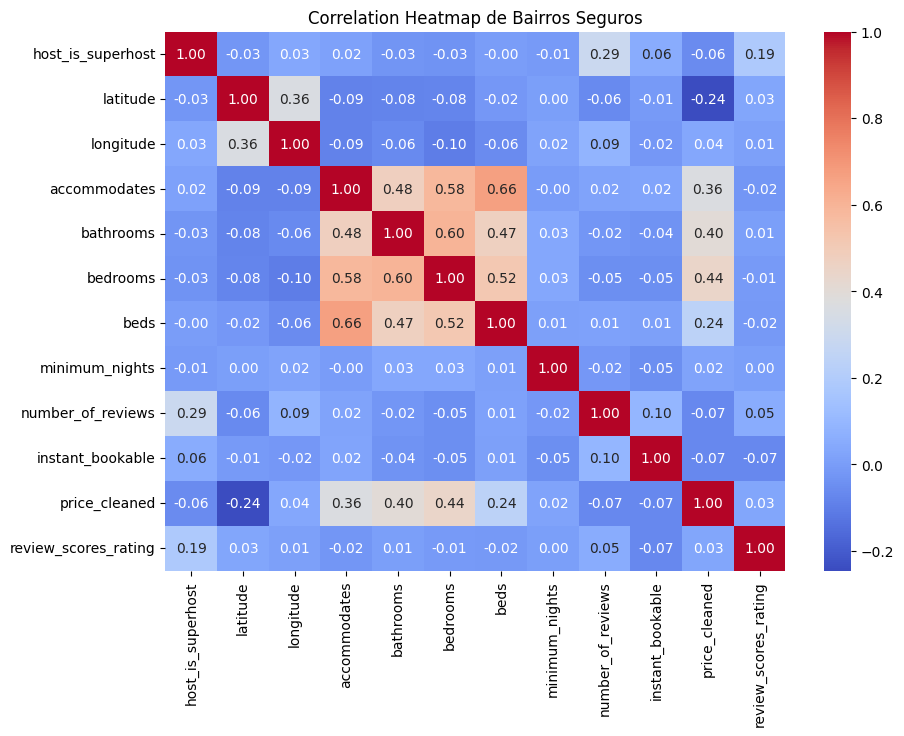

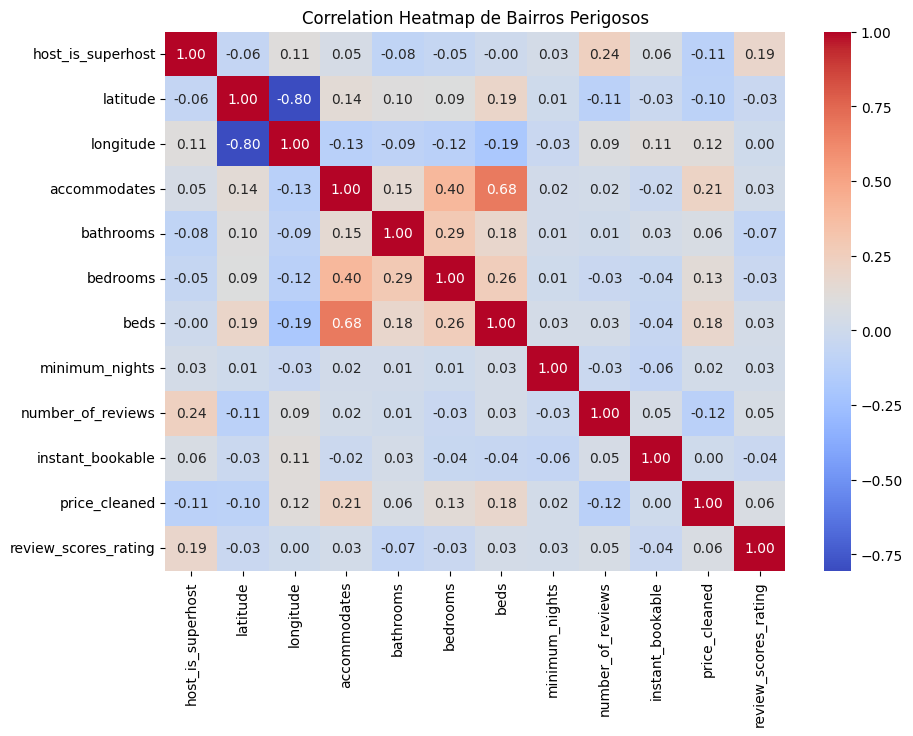

In [57]:
import seaborn as sns
plt.figure(figsize=(10, 7))
corr = dfs_por_bairro[0][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Seguros')
plt.show()

corr = dfs_por_bairro[1][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Perigosos')
plt.show()

In [58]:
cat_cols = ['host_is_superhost', 'instant_bookable']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [59]:
for bairro, dfs_escolhido in dfs_por_bairro.items():
    print("Seguro" if bairro == 0 else "Perigoso")

Seguro
Perigoso


#### Arvore

In [60]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [61]:
modelos_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [62]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_por_bairro[MODELO_ATUAL][status_bairro] = pipeline_atual
    
    predicoes_por_bairro[MODELO_ATUAL][status_bairro] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    
    metricas_por_bairro[MODELO_ATUAL][status_bairro] = {
        'R2': r2, 
        'RMSE': rmse
    }


--- Treinando arvore_normal para o grupo: Seguro ---
R² Score: 0.3842
Root mean squared error: 159.1555

--- Treinando arvore_normal para o grupo: Perigoso ---
R² Score: 0.0387
Root mean squared error: 138.2233


### Tipos de Quartos

In [63]:

dfs_por_quartos = {nome_grupo: dados.drop(columns=['room_type']) 
                 for nome_grupo, dados in df_treatment.groupby('room_type')}

In [64]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

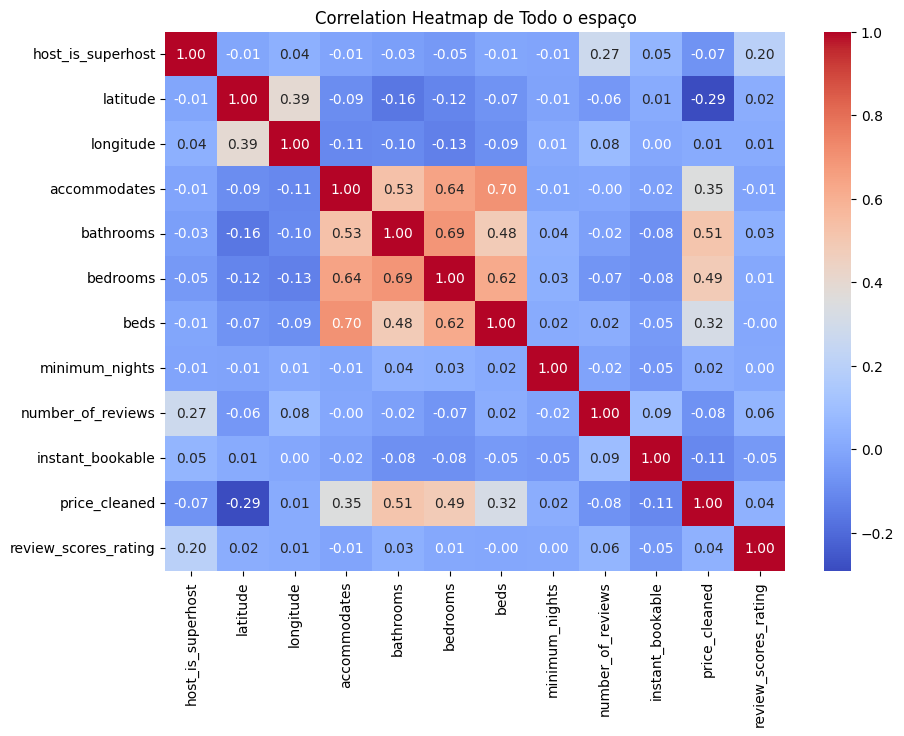

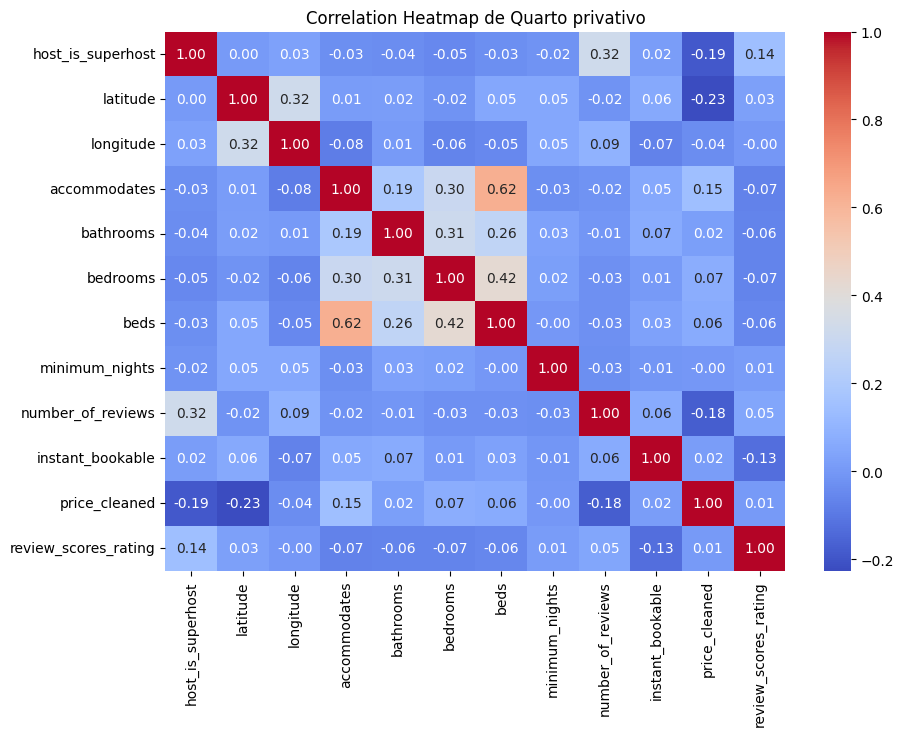

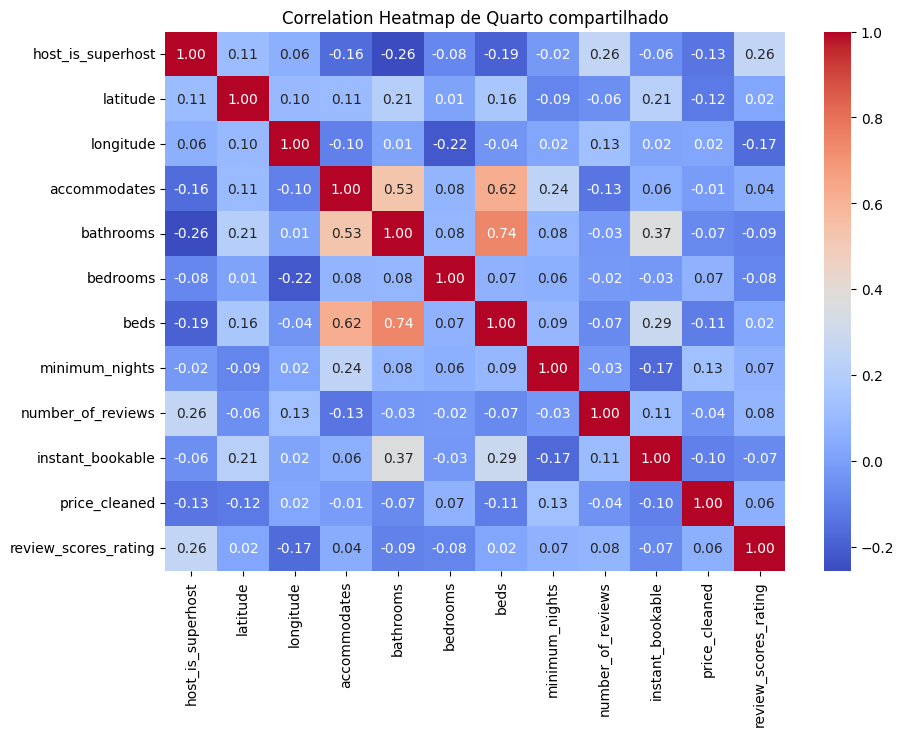

In [65]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'instant_bookable', 'price_cleaned', 'review_scores_rating'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

#### Arvore

In [66]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [67]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [68]:
modelos_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [69]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0218
Root mean squared error: 111.8877

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.2006
Root mean squared error: 148.5714

--- Treinando arvore_normal para o grupo: Todo o espaço ---
R² Score: 0.4299
Root mean squared error: 154.1207


Leve piora comparado ao modelo analisando tudo e comparando com "Todo o espaço"

In [ ]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---
R² Score: 0.0422
Root mean squared error: 108.3263


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.3247
Root mean squared error: 136.5547


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.5103
Root mean squared error: 142.8419



Resultado muito bom com XGBoost, principalmente para os dados de todo o espaço

In [81]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro'] = (df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real']

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro'] >= 0.1].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto      erro
0             19375496       186.0      278.294098  0.496205
1  1026834550578015243       468.0      595.750549  0.272971
2              2879057       192.0      268.333038  0.397568
4             27508817       150.0      274.504395  0.830029
5             43235469       136.0      111.376755  0.181053


#### Lasso

In [73]:
precomputador_lasso_quartos = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

In [74]:
from sklearn.base import clone

MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = clone(precomputador_lasso_quartos)
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    rmse = root_mean_squared_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: -5.9051
Root mean squared error: 290.8545


--- Treinando lasso para o grupo: Quarto privativo ---
R² Score: 0.2386
Root mean squared error: 144.9972


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: 0.4409
Root mean squared error: 152.6230



Modelos de lasso aqui se torna melhor que arvore regressora. $R^2_{Score}$ = 0.3342613615652218 em arvore sem separação de quartos.

Anuncios que se alugam todo o espaço esta prevendo melhor, provavelmente os outros ainda estão piorando a analise feita anteriormente, note ainda que quarto compartilhado é a pior predição de todas

In [75]:
for room in room_trad.values():
    df = dfs_por_quartos[room]
    print("O número de dados para o tipo de anúncio", room ,len(df))

O número de dados para o tipo de anúncio Todo o espaço 9144
O número de dados para o tipo de anúncio Quarto privativo 1696
O número de dados para o tipo de anúncio Quarto compartilhado 77


Talves o problema dos quartos compartilhados esteja na quantidade de dados, poucos para se tirar uma estatística concisa. O dataset tem apenas 77 dados no total. Ao dividir em treino e teste (80/20), o conjunto de teste tem apenas cerca de 15 imóveis.

In [76]:
dfs_por_quartos["Quarto compartilhado"].price_cleaned.describe()

count     77.000000
mean     117.727273
std      111.153833
min       54.000000
25%       63.000000
50%       78.000000
75%      120.000000
max      700.000000
Name: price_cleaned, dtype: float64

In [ ]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['lasso'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['lasso'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro'] = (df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real']

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro'] >= 0.1].head())

Exemplos com erro >= 10% para Todo o espaço:
            id_imovel  preço_real  preço_previsto      erro
0            19375496       186.0      335.437167  0.803426
2             2879057       192.0      213.214183  0.110491
3  730411934911173711       373.0      318.738900  0.145472
4            27508817       150.0      268.422291  0.789482
5            43235469       136.0      113.389658  0.166253


In [86]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [87]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [88]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           26941
Quarto privativo         6624
Quarto compartilhado      381
Name: count, dtype: int64

### Previsão de Rating

In [89]:
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import numpy as np
RANDOM_SEED = 42

df_rating_pred = df_rating_pred.dropna()
df_copa = df_rating_pred[df_rating_pred['neighbourhood_cleansed'] == 'Copacabana']
X = df_rating_pred.drop(columns=['review_scores_rating'])
y = df_rating_pred['review_scores_rating'].values
# X = df_copa.drop(columns=['review_scores_rating'])
# y = df_copa['review_scores_rating'].values

In [90]:
X.room_type.value_counts()

room_type
Todo o espaço           9144
Quarto privativo        1696
Quarto compartilhado      77
Name: count, dtype: int64

In [91]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_rating_pred[['room_type']]).toarray()
# one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']

Text(0.5, 1.0, 'Correlation Heatmap')

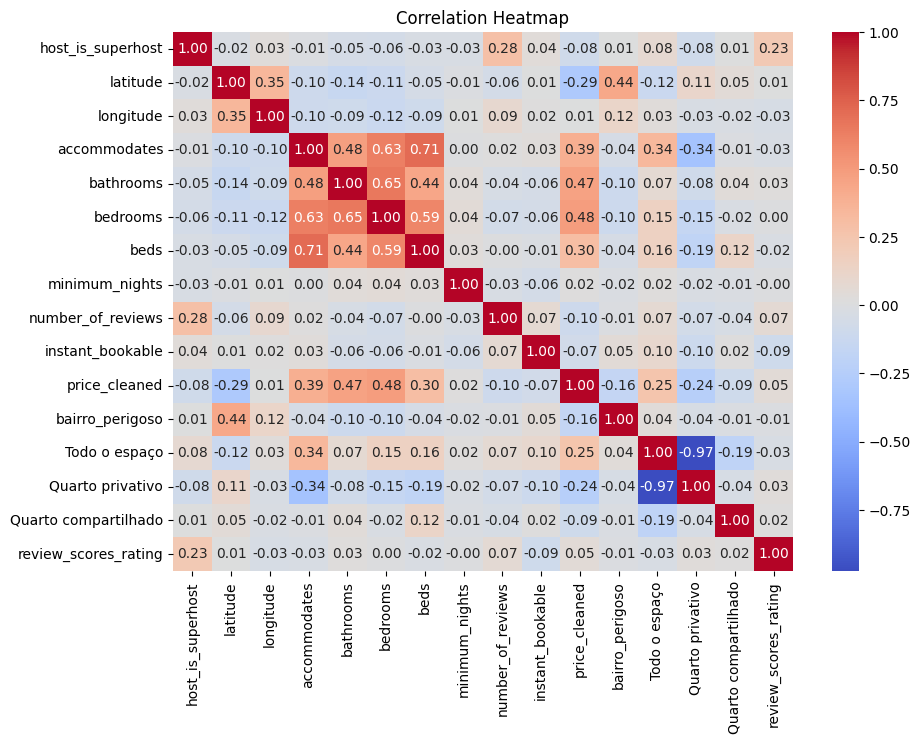

In [92]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['review_scores_rating'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')